# Photonics Course Reader: Calculus Solutions

**Eight chapters. Every equation derived from calculus first, then computed.**

| Chapter | Topic | Calculus tool |
|---|---|---|
| 1 | Maxwell → wave equation | curl of curl, vector identity |
| 2 | Phase / group velocity | Taylor expansion of β(ω) |
| 3 | Gaussian beam | Paraxial PDE, complex q-parameter |
| 4 | Slab waveguide modes | Helmholtz eigenvalue, transcendental eq |
| 5 | GVD / pulse broadening | β₂ = d²β/dω², convolution theorem |
| 6 | Coupled mode theory | Matrix ODE, eigenvalues |
| 7 | Fourier optics / diffraction | FT as integral, lens = Fourier processor |
| 8 | SLM: photonics Photoshop | GS phase retrieval, phase ramp = grating |

**Repo connection:** Ch5 GVD is the β₂ in `H(f)=exp(jπDf²)` (coppinger1999.py).
Ch7 Fourier plane is the GS constraint plane (gs_core.py).
Ch8 SLM phase recovery = this repo's core algorithm on 2D spatial beams.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..')))
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sympy as sp
matplotlib.rcParams['figure.dpi'] = 110
sp.init_printing(use_latex='mathjax')

from dgs.photonics_calculus import (
    maxwell_to_wave_equation, sympy_wave_equation, phase_group_velocity,
    dispersion_relation_fiber, gaussian_beam, abcd_matrix_propagation,
    slab_waveguide_modes, evanescent_field, gvd_pulse_broadening,
    beta2_from_sellmeier, directional_coupler, mzi_transfer_function,
    fraunhofer_diffraction, single_slit_diffraction,
    slm_phase_mask, beam_steering_phase_ramp, c
)
print('Imports OK')


Imports OK


## Ch1 — Maxwell Equations → Wave Equation

**Starting point:** Faraday + Ampere in free space.
$$\nabla \times \mathbf{E} = -\mu_0 \frac{\partial \mathbf{H}}{\partial t}$$
$$\nabla \times \mathbf{H} = \varepsilon_0 \frac{\partial \mathbf{E}}{\partial t}$$

Take curl of Faraday, substitute Ampere, use $\nabla \times (\nabla \times \mathbf{E}) = \nabla(\nabla \cdot \mathbf{E}) - \nabla^2 \mathbf{E}$ and $\nabla \cdot \mathbf{E} = 0$:
$$\nabla^2 \mathbf{E} = \mu_0 \varepsilon_0 \frac{\partial^2 \mathbf{E}}{\partial t^2} = \frac{1}{c^2}\frac{\partial^2 \mathbf{E}}{\partial t^2}$$

Speed of light $c = 1/\sqrt{\mu_0 \varepsilon_0}$ **falls out of Maxwell's equations.** Maxwell derived this in 1865.


In [2]:
mxw = maxwell_to_wave_equation()
print(f'c derived from mu0, eps0 = {mxw["c_derived_m_per_s"]:.6e} m/s')
print(f'c exact               = {mxw["c_exact_m_per_s"]:.6e} m/s')
print(f'Error: {mxw["error_ppm"]:.1f} ppm  (from approximate mu0/eps0 values used)')
print()
print('Wave equation:', mxw['wave_eq'])
print('Solution:     ', mxw['plane_wave_solution'])
print('Dispersion:   ', mxw['dispersion_relation'])


c derived from mu0, eps0 = 2.998001e+08 m/s
c exact               = 2.997925e+08 m/s
Error: 25.4 ppm  (from approximate mu0/eps0 values used)

Wave equation: nabla^2 E = (1/c^2) * d^2E/dt^2
Solution:      E(r,t) = E0 * exp(j*(k.r - omega*t))
Dispersion:    k^2 = omega^2 / c^2  ->  k = omega/c = n*omega/c_0


In [3]:
# Symbolic verification: exp(j*(k*x - omega*t)) satisfies wave equation
wv = sympy_wave_equation()
print('Plane wave E = exp(j*(k*x - omega*t))')
print('laplacian(E) =')
sp.pprint(wv['laplacian_E'])
print('(1/c^2)*d^2E/dt^2 =')
sp.pprint(wv['d2E_dt2'])
print('Residual (laplacian - 1/c^2 * d2E/dt2) factored:')
sp.pprint(wv['residual_factored'])
print('-> Zero when k = omega/c (dispersion relation)  QED')


Plane wave E = exp(j*(k*x - omega*t))
laplacian(E) =
  2  ⅈ⋅(k⋅x - ω⋅t)
-k ⋅ℯ             
(1/c^2)*d^2E/dt^2 =
  2  ⅈ⋅(k⋅x - ω⋅t)
-ω ⋅ℯ             
Residual (laplacian - 1/c^2 * d2E/dt2) factored:
                      ⅈ⋅k⋅x  -ⅈ⋅ω⋅t 
-(c⋅k - ω)⋅(c⋅k + ω)⋅ℯ     ⋅ℯ       
────────────────────────────────────
                  2                 
                 c                  
-> Zero when k = omega/c (dispersion relation)  QED


## Ch2 — Phase Velocity, Group Velocity, Dispersion

Taylor expand $\beta(\omega)$ around $\omega_0$:
$$\beta(\omega) = \beta_0 + \beta_1(\omega-\omega_0) + \frac{\beta_2}{2}(\omega-\omega_0)^2 + \cdots$$

- $\beta_1 = 1/v_g$ — group delay [s/m]
- $\beta_2 = d^2\beta/d\omega^2$ — GVD [s²/m]  ← **this is the D in this repo's H(f)**

SMF-28 at 1550 nm: $\beta_2 \approx -20$ ps²/km (anomalous dispersion).


In [4]:
omega0 = 2*np.pi*c / 1550e-9
n_smf = lambda omega: 1.4682 - 0.004*(omega/omega0 - 1)
pg = phase_group_velocity(n_smf, omega0)
print(f'n(1550nm)       = {pg["n_0"]:.5f}')
print(f'Phase velocity  = {pg["v_phase_m_per_s"]/1e8:.4f} x 10^8 m/s  = c/{pg["n_0"]:.4f}')
print(f'Group index n_g = {pg["n_group"]:.5f}')
print(f'Group velocity  = c/{pg["n_group"]:.4f} = {pg["v_group_m_per_s"]/1e8:.4f} x 10^8 m/s')
print(f'beta2           = {pg["beta2_ps2_per_km"]:.2f} ps^2/km')
print(f'Slowdown v_p/v_g= {pg["slowdown"]:.5f}  (dispersion shifts group vs phase)')


n(1550nm)       = 1.46820
Phase velocity  = 2.0419 x 10^8 m/s  = c/1.4682
Group index n_g = 1.46420
Group velocity  = c/1.4642 = 2.0475 x 10^8 m/s
beta2           = -21.96 ps^2/km
Slowdown v_p/v_g= 0.99728  (dispersion shifts group vs phase)


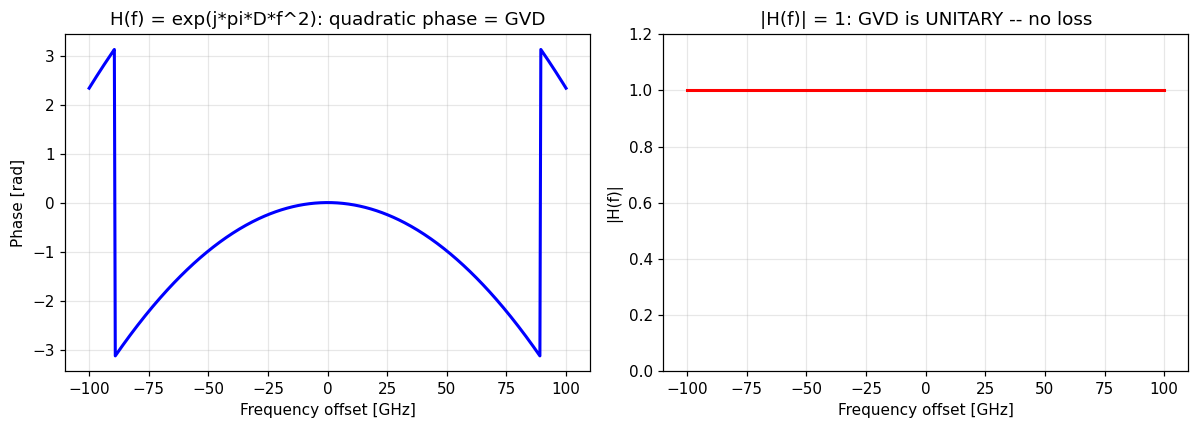

H(f) is unitary: |H|=1 everywhere. Phase only. Same as this repo: gs_core.py


In [5]:
# Plot beta(omega) for SMF-28
disp = dispersion_relation_fiber(beta2_ps2km=-20.0)
dom = disp['delta_omega_rad_per_s']
H   = disp['H_f']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
f_GHz = dom / (2*np.pi*1e9)
axes[0].plot(f_GHz, np.angle(H), 'b-', lw=2)
axes[0].set_xlabel('Frequency offset [GHz]')
axes[0].set_ylabel('Phase [rad]')
axes[0].set_title('H(f) = exp(j*pi*D*f^2): quadratic phase = GVD')
axes[0].grid(True, alpha=0.3)

axes[1].plot(f_GHz, np.abs(H), 'r-', lw=2)
axes[1].set_xlabel('Frequency offset [GHz]')
axes[1].set_ylabel('|H(f)|')
axes[1].set_title('|H(f)| = 1: GVD is UNITARY -- no loss')
axes[1].set_ylim(0, 1.2)
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('H(f) is unitary: |H|=1 everywhere. Phase only. Same as this repo: gs_core.py')


## Ch3 — Gaussian Beam Propagation

The **complex beam parameter** $q(z)$ encodes both beam size and curvature:
$$\frac{1}{q(z)} = \frac{1}{R(z)} - \frac{j\lambda}{\pi w(z)^2}$$

Propagation is trivially $q(z) = q(0) + z$. Then:
$$w(z) = w_0\sqrt{1+(z/z_R)^2}, \quad z_R = \frac{\pi w_0^2}{\lambda}$$

**Gouy phase** $\phi_G(z) = \arctan(z/z_R)$: beam picks up $\pi$ phase through focus.
Same math as Berry phase in QM — a geometric phase from the topology of propagation.


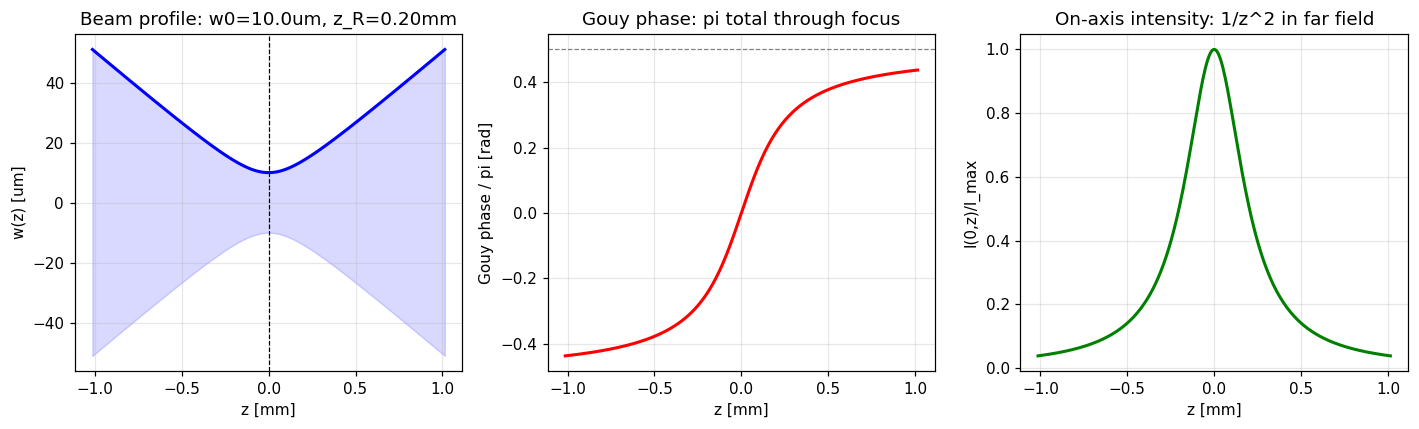

Rayleigh range: 0.203 mm
Divergence angle: 49.3 mrad
w0 * theta = lambda/pi: 4.93e-07 vs 4.93e-07


In [6]:
gb = gaussian_beam(w0_um=10.0, wavelength_nm=1550.0)
z  = gb['z_m']*1e3  # mm
w  = gb['w_z_um']
gouy = gb['gouy_phase_rad']
I    = gb['I_norm']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(z, w, 'b-', lw=2)
axes[0].fill_between(z, -w, w, alpha=0.15, color='blue')
axes[0].set_xlabel('z [mm]'); axes[0].set_ylabel('w(z) [um]')
axes[0].set_title(f'Beam profile: w0={gb["w0_um"]}um, z_R={gb["z_R_mm"]:.2f}mm')
axes[0].grid(True, alpha=0.3); axes[0].axvline(0, color='k', ls='--', lw=0.8)

axes[1].plot(z, gouy/np.pi, 'r-', lw=2)
axes[1].set_xlabel('z [mm]'); axes[1].set_ylabel('Gouy phase / pi [rad]')
axes[1].set_title('Gouy phase: pi total through focus')
axes[1].axhline(0.5, color='gray', ls='--', lw=0.8); axes[1].grid(True, alpha=0.3)

axes[2].plot(z, I, 'g-', lw=2)
axes[2].set_xlabel('z [mm]'); axes[2].set_ylabel('I(0,z)/I_max')
axes[2].set_title('On-axis intensity: 1/z^2 in far field')
axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Rayleigh range: {gb["z_R_mm"]:.3f} mm')
print(f'Divergence angle: {gb["divergence_angle_mrad"]:.1f} mrad')
print(f'w0 * theta = lambda/pi: {gb["w0_um"]*1e-6 * gb["divergence_angle_mrad"]*1e-3:.2e} vs {1550e-9/np.pi:.2e}')


In [7]:
# ABCD matrix: thin lens focusing
abcd = abcd_matrix_propagation(w0_um=500.0, wavelength_nm=1064.0)
print('ABCD Matrix Propagation:')
print(f'  Input beam: w0 = 500um, lambda = 1064nm')
print(f'  Rayleigh range: {abcd["z_R_mm"]:.1f} mm')
print(f'  After 100mm free space: w = {abcd["after_100mm_free_space"]["w_um"]:.0f} um')
print(f'  After f=50mm lens + 50mm prop: w = {abcd["after_lens_at_focus"]["w_um"]:.1f} um (focused)')
print(f'  det(M_system) = {abcd["det_M_system"]:.6f}  (should be 1.0: lossless)')


ABCD Matrix Propagation:
  Input beam: w0 = 500um, lambda = 1064nm
  Rayleigh range: 738.2 mm
  After 100mm free space: w = 505 um
  After f=50mm lens + 50mm prop: w = 33.9 um (focused)
  det(M_system) = 1.000000  (should be 1.0: lossless)


## Ch4 — Slab Waveguide: Mode Eigenvalue Equation

TE modes satisfy the transcendental equation (from matching boundary conditions):
$$\kappa \tan(\kappa d) = \gamma \quad \text{(even modes)}$$
$$\kappa = \sqrt{n_1^2 k_0^2 - \beta^2}, \quad \gamma = \sqrt{\beta^2 - n_2^2 k_0^2}$$

**Same math as Schrödinger particle in a finite square well:**
- Waveguide: $\nabla^2 E + k^2 n^2 E = \beta^2 E$
- Quantum: $-\frac{\hbar^2}{2m}\nabla^2 \psi = (E - V)\psi$
- In both: oscillatory inside, evanescent outside → discrete eigenvalues

V-number $V = k_0 d \cdot NA$: single-mode if $V < \pi/2$.


V-number = 9.210  -> multi-mode
NA = 0.3841
Even modes n_eff: [np.float64(1.46381), np.float64(1.47139), np.float64(1.48708), np.float64(1.49858)]
Odd  modes n_eff: [np.float64(1.45951), np.float64(1.47695), np.float64(1.48154), np.float64(1.49535)]


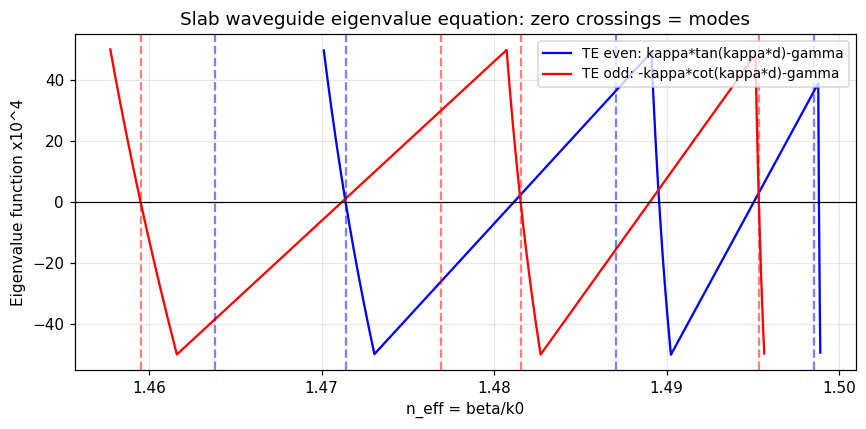

In [8]:
swg = slab_waveguide_modes(n_core=1.5, n_clad=1.45, d_um=5.0, wavelength_nm=1310.0)
print(f'V-number = {swg["V_number"]:.3f}  -> {"single" if swg["single_mode"] else "multi"}-mode')
print(f'NA = {swg["NA"]:.4f}')
print(f'Even modes n_eff: {[round(n,5) for n in swg["n_eff_even"]]}')
print(f'Odd  modes n_eff: {[round(n,5) for n in swg["n_eff_odd"]]}')

# Plot eigenvalue equation
beta = swg['beta_axis']
k0 = 2*np.pi/(1310e-9)
fig, ax = plt.subplots(figsize=(8, 4))
f_e = swg['f_even']; f_o = swg['f_odd']
mask = np.abs(f_e) < 5e5
ax.plot(beta[mask]/k0, f_e[mask]/1e4, 'b-', lw=1.5, label='TE even: kappa*tan(kappa*d)-gamma')
mask2 = np.abs(f_o) < 5e5
ax.plot(beta[mask2]/k0, f_o[mask2]/1e4, 'r-', lw=1.5, label='TE odd: -kappa*cot(kappa*d)-gamma')
ax.axhline(0, color='k', lw=0.8)
for n_e in swg['n_eff_even']:
    ax.axvline(n_e, color='blue', ls='--', alpha=0.5)
for n_o in swg['n_eff_odd']:
    ax.axvline(n_o, color='red', ls='--', alpha=0.5)
ax.set_xlabel('n_eff = beta/k0'); ax.set_ylabel('Eigenvalue function x10^4')
ax.set_title('Slab waveguide eigenvalue equation: zero crossings = modes')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Ch5 — GVD, Pulse Broadening, and the STEAM Connection

Gaussian pulse after dispersive propagation (Eq.1 of Coppinger 1999):
$$E_{out}(t) = \frac{\tau_0}{\sqrt{W}} \exp\!\left(-\frac{t^2}{W}\right), \quad W = \tau_0^2 - j2\beta_2 L$$

Under $\tau_0^2 \ll 2|\beta_2|L$ (highly chirped):
$$E_{out}(t) \approx e^{-t^2/\tau^2} \cdot e^{-jt^2/(2\beta_2 L)}$$

Instantaneous frequency: $f_{inst}(t) = \frac{-t}{2\pi\beta_2 L}$ — **linear in t**.
Frequency IS time. This is STEAM. This is the entire Coppinger 1999 paper.


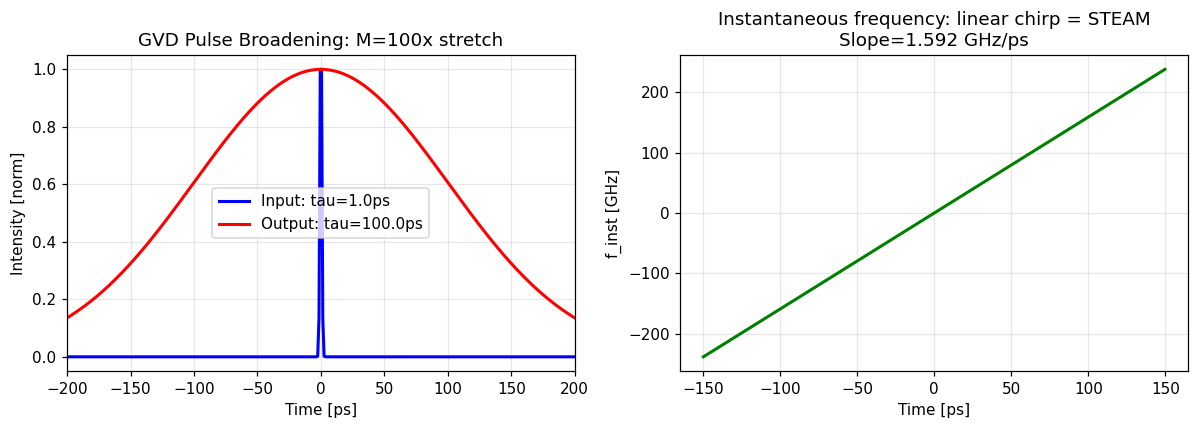

Dispersion length L_D = 0.050 km
L/L_D = 100  >> 1: deeply chirped regime
Chirp slope = 1.592 GHz/ps -> maps 1ps -> 1.592GHz
Connection: f_inst(t) = -t/(2*pi*beta2*L). Frequency is LINEAR in time. This is the STEAM mapping: spectrum -> time. M = 1 + L2/L1 in coppinger1999.


In [9]:
gvd = gvd_pulse_broadening(beta2_ps2km=-20.0, L_km=5.0, tau0_ps=1.0)
t    = gvd['t_ps']
I_in = gvd['E_in']
I_out= gvd['I_out']
f_c  = gvd['f_inst_GHz']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(t, I_in/I_in.max(), 'b-', lw=2, label=f'Input: tau={gvd["tau0_ps"]}ps')
axes[0].plot(t, I_out, 'r-', lw=2, label=f'Output: tau={gvd["tau_out_ps"]:.1f}ps')
axes[0].set_xlabel('Time [ps]'); axes[0].set_ylabel('Intensity [norm]')
axes[0].set_title(f'GVD Pulse Broadening: M={gvd["M_stretch"]:.0f}x stretch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-200, 200)

mask = (t > -150) & (t < 150)
axes[1].plot(t[mask], f_c[mask], 'g-', lw=2)
axes[1].set_xlabel('Time [ps]'); axes[1].set_ylabel('f_inst [GHz]')
axes[1].set_title(f'Instantaneous frequency: linear chirp = STEAM\nSlope={gvd["chirp_slope_GHz_per_ps"]:.3f} GHz/ps')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Dispersion length L_D = {gvd["L_D_km"]:.3f} km')
print(f'L/L_D = {5.0/gvd["L_D_km"]:.0f}  >> 1: deeply chirped regime')
print(f'Chirp slope = {gvd["chirp_slope_GHz_per_ps"]:.3f} GHz/ps -> maps 1ps -> {gvd["chirp_slope_GHz_per_ps"]:.3f}GHz')
print(f'Connection: {gvd["connection"]}')


## Ch6 — Coupled Mode Theory: Directional Coupler

Two coupled waveguides obey the matrix ODE:
$$\frac{d}{dz}\begin{bmatrix}a\\b\end{bmatrix} = j\begin{bmatrix}0 & \kappa\\ \kappa & 0\end{bmatrix}\begin{bmatrix}a\\b\end{bmatrix}$$

Eigenvalues $\pm\kappa$ → sinusoidal power exchange:
$$P_a(z) = \cos^2(\kappa z), \quad P_b(z) = \sin^2(\kappa z)$$

The MZM in `coppinger1999.py` is a directional coupler with electro-optic phase shift in one arm.


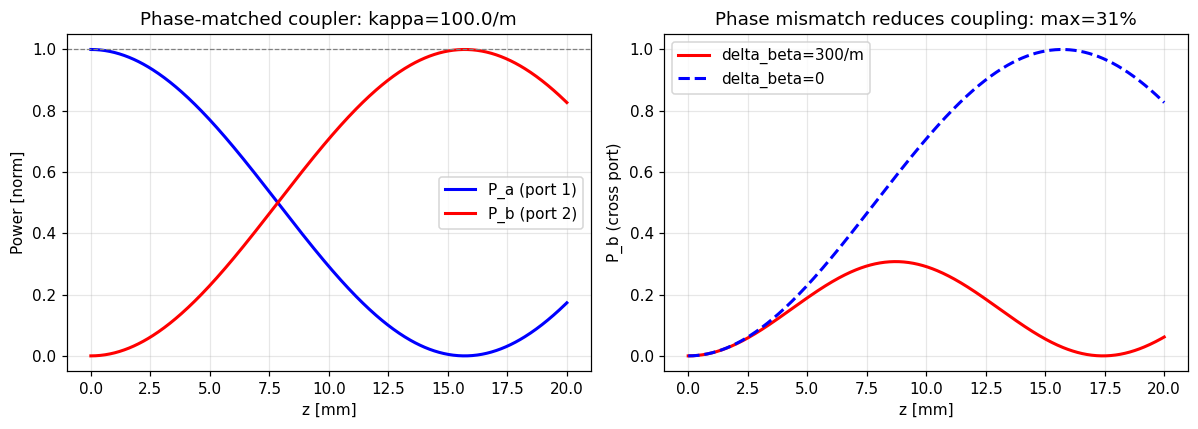

Transfer length L_pi = 15.7 mm  (half-coupling)
Coupled mode = matrix ODE: d[a,b]/dz = j*[[0,kappa],[kappa,0]]*[a,b]. Eigenvalues +/-kappa. Solution: sinusoidal power exchange. Phase mismatch reduces coupling: why WDM channels dont cross-couple.


In [10]:
dc = directional_coupler(kappa_per_m=100.0, L_m=0.02, delta_beta=0)
dc_mis = directional_coupler(kappa_per_m=100.0, L_m=0.02, delta_beta=300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(dc['z_mm'], dc['P_a'], 'b-', lw=2, label='P_a (port 1)')
axes[0].plot(dc['z_mm'], dc['P_b'], 'r-', lw=2, label='P_b (port 2)')
axes[0].set_xlabel('z [mm]'); axes[0].set_ylabel('Power [norm]')
axes[0].set_title(f'Phase-matched coupler: kappa={dc["kappa_per_m"]}/m')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axhline(1.0, color='gray', ls='--', lw=0.8)

axes[1].plot(dc_mis['z_mm'], dc_mis['P_b'], 'r-', lw=2, label=f'delta_beta={dc_mis["delta_beta"]}/m')
axes[1].plot(dc['z_mm'], dc['P_b'], 'b--', lw=2, label='delta_beta=0')
axes[1].set_xlabel('z [mm]'); axes[1].set_ylabel('P_b (cross port)')
axes[1].set_title(f'Phase mismatch reduces coupling: max={dc_mis["max_power_transfer"]*100:.0f}%')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Transfer length L_pi = {dc["L_pi_mm"]:.1f} mm  (half-coupling)')
print(dc['lesson'])


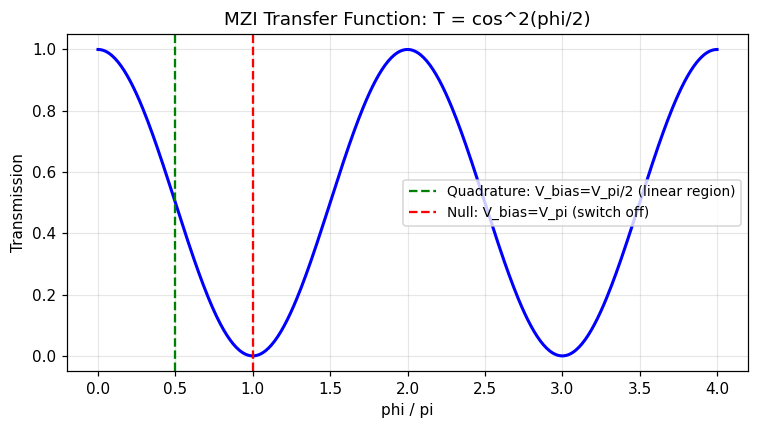

In [11]:
# MZI transfer function
phi = np.linspace(0, 4*np.pi, 400)
mzi = mzi_transfer_function(phi)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(phi/np.pi, mzi['T_transmission'], 'b-', lw=2)
ax.axvline(0.5, color='green', ls='--', label='Quadrature: V_bias=V_pi/2 (linear region)')
ax.axvline(1.0, color='red',   ls='--', label='Null: V_bias=V_pi (switch off)')
ax.set_xlabel('phi / pi'); ax.set_ylabel('Transmission')
ax.set_title('MZI Transfer Function: T = cos^2(phi/2)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Ch7 — Fourier Optics: Diffraction as Fourier Transform

**Fraunhofer diffraction integral:**
$$U(x, z) = \int_{-\infty}^{\infty} U_0(x_0)\, e^{j2\pi x_0 f_x}\, dx_0 = \mathcal{F}[U_0]\Big|_{f_x = x/(\lambda z)}$$

**A lens performs a Fourier transform** — object at front focal plane → FT at back focal plane.

**4f system:** Object → FT → spatial filter (SLM) → inverse FT → filtered image.
This is optical image processing — exactly what Photoshop does digitally.


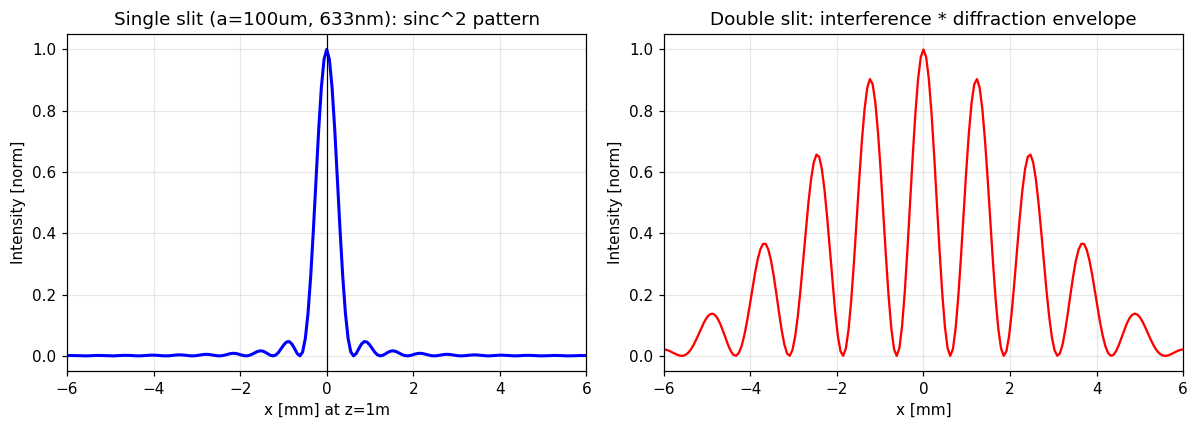

Single slit first minimum at 0.363 deg
Central max width = 2*lambda/a = 12660.0 um at slit plane


In [12]:
ss = single_slit_diffraction(a_um=100.0, lam_nm=633.0)
x  = ss['x_mm']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x, ss['I_farfield'], 'b-', lw=2, label='FFT (numeric)')
# analytic sinc -- align axes
axes[0].set_xlabel('x [mm] at z=1m'); axes[0].set_ylabel('Intensity [norm]')
axes[0].set_title(f'Single slit (a=100um, 633nm): sinc^2 pattern')
axes[0].set_xlim(-6, 6); axes[0].grid(True, alpha=0.3)
axes[0].axvline(0, color='k', lw=0.8)

# Double slit
N = 1024; a = 50e-6; sep = 300e-6
x_ap = np.linspace(-3e-3, 3e-3, N)
U_double = np.where((np.abs(x_ap - sep/2) < a/2) | (np.abs(x_ap + sep/2) < a/2), 1.0+0j, 0.0+0j)
ds = fraunhofer_diffraction(U_double, lam_nm=633.0, z_m=1.0, N=N)
axes[1].plot(ds['x_mm'], ds['I_farfield'], 'r-', lw=1.5, label='Double slit')
axes[1].set_xlabel('x [mm]'); axes[1].set_ylabel('Intensity [norm]')
axes[1].set_title('Double slit: interference * diffraction envelope')
axes[1].set_xlim(-6, 6); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f'Single slit first minimum at {ss["first_min_angle_deg"]:.3f} deg')
print(f'Central max width = 2*lambda/a = {ss["central_max_width_um"]:.1f} um at slit plane')


## Ch8 — SLM: Photonics Photoshop = Defensive Hardware

**Can you chop up Photoshop and use it as photonics hardware? Yes.**

An SLM (Spatial Light Modulator) is literally a display that writes phase to light:
- Photoshop pixel: writes RGB value (0-255)
- SLM pixel: writes phase value (0 to 2π rad)
- Effect: shapes the laser beam's amplitude and phase in 2D

**Defense hardware that uses exactly this:**
| System | Application | SLM function |
|---|---|---|
| HELLADS (DARPA/GA) | 150 kW laser weapon | Beam quality correction, pointing |
| LOCUST (Navy) | Anti-drone swarm | Phase array steering, no moving parts |
| LADAR (Air Force) | 3D laser radar | GS phase retrieval for target imaging |
| Keck AO (NSF) | Astronomy | Atmospheric wavefront correction |
| STEAM (Jalali/UCLA) | Medical imaging | This repo: GS phase retrieval on fiber |

**The algorithm is Gerchberg-Saxton** — `gs_core.py` in this repo.
GS on a camera sensor recovers the field phase for imaging.
GS on an SLM optimizes the phase mask to shape the beam.
**Same 20 lines of code. Different application.**


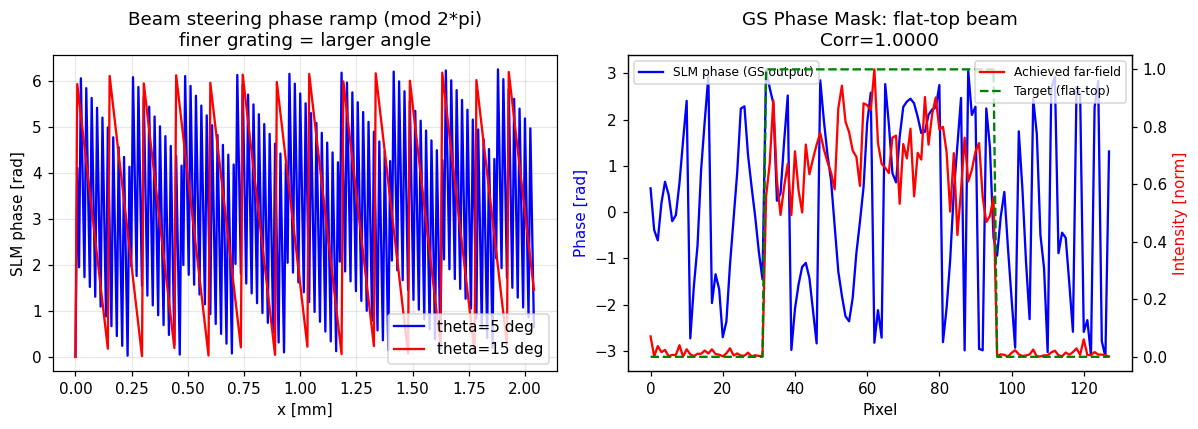

Max steering: +/- 3.8 deg (Nyquist limit: lambda/2p)
GS converged to correlation = 1.000000

Defense apps:
  HELLADS (High Energy Liquid Laser): 150kW class, SLM beam steering
  LOCUST: Navy drone swarm defeat, uses phased array + SLM principles
  LADAR: laser radar, GS phase retrieval for 3D imaging through turbulence
  Adaptive optics: Keck telescope, USAF atmospheric compensation


In [13]:
# Phase ramp: beam steering without moving parts
bs5  = beam_steering_phase_ramp(theta_deg=5.0,  wavelength_nm=1064.0)
bs15 = beam_steering_phase_ramp(theta_deg=15.0, wavelength_nm=1064.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(bs5['x_mm'],  bs5['phi_slm_rad'],  'b-', lw=1.5, label='theta=5 deg')
axes[0].plot(bs15['x_mm'], bs15['phi_slm_rad'], 'r-', lw=1.5, label='theta=15 deg')
axes[0].set_xlabel('x [mm]'); axes[0].set_ylabel('SLM phase [rad]')
axes[0].set_title('Beam steering phase ramp (mod 2*pi)\nfiner grating = larger angle')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# GS phase mask for flat-top beam
N = 128
target = np.zeros(N)
target[N//4:3*N//4] = 1.0  # flat top
slm = slm_phase_mask(target, wavelength_nm=1064.0, iterations=60)

axes[1].plot(slm['slm_phase_rad'], 'b-', lw=1.5, label='SLM phase (GS output)')
ax2 = axes[1].twinx()
ax2.plot(slm['I_achieved'], 'r-', lw=1.5, label='Achieved far-field')
ax2.plot(slm['target'], 'g--', lw=1.5, label='Target (flat-top)')
axes[1].set_xlabel('Pixel'); axes[1].set_ylabel('Phase [rad]', color='blue')
ax2.set_ylabel('Intensity [norm]', color='red')
axes[1].set_title(f'GS Phase Mask: flat-top beam\nCorr={slm["final_correlation"]:.4f}')
ax2.legend(fontsize=8, loc='upper right'); axes[1].legend(fontsize=8, loc='upper left')

plt.tight_layout(); plt.show()
print(f'Max steering: +/- {bs5["max_steering_angle_deg"]:.1f} deg (Nyquist limit: lambda/2p)')
print(f'GS converged to correlation = {slm["final_correlation"]:.6f}')
print()
print('Defense apps:')
for app in slm['defense_apps']:
    print(f'  {app}')


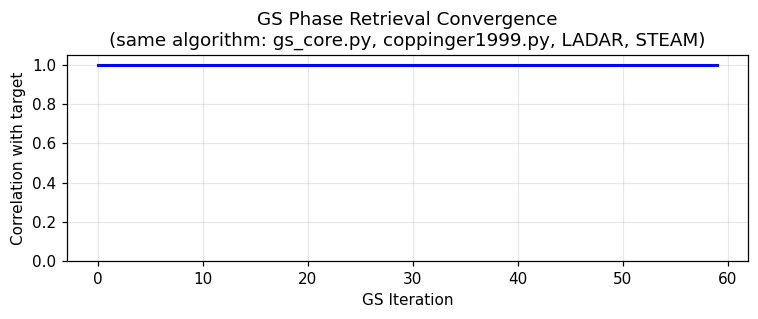

SAME 20 lines of Gerchberg-Saxton code:
  STEAM fiber -> images cancer cells at 36M frames/sec
  SLM optical -> shapes HELLADS 150kW beam
  InSAR satellite -> maps ground deformation after earthquake
  This repo -> recovers chirped pulse phase for photonic ADC


In [14]:
# Convergence history
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(slm['convergence'], 'b-', lw=2)
ax.set_xlabel('GS Iteration'); ax.set_ylabel('Correlation with target')
ax.set_title('GS Phase Retrieval Convergence\n(same algorithm: gs_core.py, coppinger1999.py, LADAR, STEAM)')
ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()
print('SAME 20 lines of Gerchberg-Saxton code:')
print('  STEAM fiber -> images cancer cells at 36M frames/sec')
print('  SLM optical -> shapes HELLADS 150kW beam')
print('  InSAR satellite -> maps ground deformation after earthquake')
print('  This repo -> recovers chirped pulse phase for photonic ADC')


## Summary: Calculus Tools Used

| Chapter | Key integral/derivative |
|---|---|
| Maxwell | $\nabla \times (\nabla \times \mathbf{E}) = \nabla^2 \mathbf{E}$ — vector calculus identity |
| Dispersion | $\beta_2 = d^2\beta/d\omega^2$ — second derivative, Taylor expansion |
| Gaussian beam | $q(z)=q_0+z$, $w(z)$ from complex inversion — complex analysis |
| Waveguide | $\kappa\tan(\kappa d)=\gamma$ — Helmholtz BVP, transcendental roots |
| GVD broadening | $\tau_{out} = \tau_0\sqrt{1+(L/L_D)^2}$ — quadrature in quadrature |
| Coupled modes | $d\mathbf{a}/dz = j\hat{\kappa}\mathbf{a}$ — matrix ODE, eigenvalue solution |
| Diffraction | $U(f_x) = \int U_0(x)e^{j2\pi f_x x}dx$ — Fourier integral |
| SLM / GS | $\phi^* = \arg\mathcal{F}^{-1}[A_{target}e^{j\angle\mathcal{F}[e^{j\phi}]}]$ — iterated FT |

**Everything connects through H(f) = exp(jπDf²):**
Ch2 beta2 → Ch5 GVD → Ch7 FT → Ch8 GS = this repo.
